# Quasi-steady simulation of a test-bench log

This notebook takes an hour-long time-series log from a test bench
(`data/experimental_data_MEA62_condition_B.csv`, MEA62) and replays the logged
setpoints through `ExplicitSteadyStateModel`.

1. Load the log from `data/experimental_data_MEA62_condition_B.csv`.
2. Assemble the MEA62 cell using the 18-parameter estimation result from
   `08_parameter_estimation.ipynb`.
3. Pack all active samples into a single `CellConditions` with array-valued
   fields and call `ExplicitSteadyStateModel.solve` once (vectorised).
4. Compare the simulated and measured cell voltage over time.

**Quasi-static approximation.** Each 1-second sample is treated as an independent
steady-state operating point — thermal and water transients between samples are
ignored. Notebook 05 (`05_transient_vs_quasi_steady.ipynb`) benchmarks this
approximation against the full `TransientModel`.

**Caveat.** Samples with `I_Pile(A)` near zero are excluded because the
steady-state model is not well-defined at zero current.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd

## 1 — Load the log

In [3]:
df = pd.read_csv('data/experimental_data_MEA62_condition_B.csv', sep=';', skiprows=6, encoding='latin1')
df = df.rename(columns=lambda c: c.strip())

# The header row has one fewer name than the data has columns: the first
# (unnamed) data column -- which pandas turns into the index -- holds the
# real `Time(s)`, and every named column is shifted one position to the
# left of its data. Re-align the column names accordingly.
old_columns = list(df.columns)
df = df.reset_index()
df.columns = ['Time(s)'] + old_columns[1:] + ['_extra']
df = df.drop(columns=['_extra'])

df['Time(h)'] = (df['Time(s)'] - df['Time(s)'].iloc[0]) / 3600.
df[['Time(h)', 'I_Pile(A)', 'U_Pile(V)', 'T_pile(°C)']].describe()

,Time(h),I_Pile(A),U_Pile(V),T_pile(°C)
count,26565.000000,26565.000000,26565.000000,26565.000000
mean,3.691196,8.503236,0.568981,73.120151
std,2.130925,10.521410,0.329847,9.809259
min,0.000000,0.000000,-0.007000,19.440000
25%,1.845939,0.000000,0.136000,70.140000
50%,3.690661,2.003000,0.707000,70.480000
75%,5.536772,14.913000,0.809000,80.200000
max,7.382136,39.431000,0.938000,80.720000


## 2 — Cell parameters and assembly

MEA62 18-parameter estimation result from `08_parameter_estimation.ipynb`
(n = 18, left-out test case: condition 2).

Ionomer transport properties (conductivity, water diffusivity, absorption
coefficient) are encapsulated in a `PFSAIonomer` instance shared between
the `PFSA` membrane and the `PtCCatalystLayer`. The `FuelCell` assembles
the full MEA as a tree of nested dataclasses — see
`01_cell_assembly_and_polarization_curve.ipynb` for a step-by-step guide.

In [4]:
# Parameters not estimated for n=18 (held at initial guess).
fixed_parameters = {
    'ionomer-k1': 8.5,
    'ionomer-k2': 5.4,
    'ionomer-k3': 5.4,
    'gdl-porosity': 0.6,
    'pt-wt-percent': 0.4,
    'ch-height': 1e-3,
    'cl-thermal-cond': 0.22,
    'radius-carbon':    25e-9,
    'n_s':              2.0,
    'gdl-thickness':    150e-6,
    'gdl-theta':        120.,
    'cl-abs-perm':      1e-13,
    'wet-transition':   0.4,
    'pt-loading':       0.3e-2,
    'ic-ratio':         1.4,
    'ecsa':             60e3,
    'memb-water-diff':  2e-10,
    'E-act-memb-diff':  20e6,
    'E-act-memb-abs':   20e6,
    'cl-theta':         97.,
    'cl-pore-diameter': 40e-9,
    'memb-abs-constant': 1e-5,
    'ionomer-E-act-cond': 15e6,
    'gdl-abs-perm':     1e-12,
}

# n_parameters = 18, fold_id = 2
estimated_parameters = {
    'elec-resistance':    3.467066875230129e-06,
    'alpha-c':            0.7281026506034132,
    'memb-cond-correction': 6.603921200288415,
    'B_ch':               1.5707938930296386,
    'ionomer-cond-corr':  1.0014324710948628,
    'i0-c':               0.0052142466891489,
    'E-act-ca':           58021540.64049202,
    'Sh':                 5.092865788506584,
    'gdl-thermal-cond':   0.0537423180937266,
    'memb-cond-exp':      1.3016511335718035,
    'memb-E-act-cond':    10196649.668377291,
    'memb-equiv-weight':  736.8899983350187,
    'gamma-c':            0.5772515728460474,
    'ix-corr':            1.999992272560833,
    'ionomer-cond-exp':   1.0537000908617322,
    'gdl-eff-diff-ratio': 0.1128415726042086,
    'memb-thickness':     9.65515328126366e-06,
    'tcr':                0.0006373882878159,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params['memb-equiv-weight'],
            dry_density=2000.,
            conductivity_exp=params['memb-cond-exp'],
            conductivity_activation_energy=params['memb-E-act-cond'],
            conductivity_correction=params['memb-cond-correction'],
            reference_water_diffusivity=params['memb-water-diff'],
            reference_water_absorption_coefficient=params['memb-abs-constant'],
            water_diffusivity_activation_energy=params['E-act-memb-diff'],
            water_absorption_activation_energy=params['E-act-memb-abs'],
        ),
        dry_thickness=params['memb-thickness'],
    )

    orr_kinetics = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = mrpd.DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: mrpd.GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=mrpd.PorousGasDiffusionModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: mrpd.FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=mrpd.ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = mrpd.PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'],
        ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'],
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'],
        contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'],
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )

    return mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=mrpd.FuelCellSide(
            cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
            thermal_contact_resistance=params['tcr'],
        ),
        an=mrpd.FuelCellSide(
            cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
            thermal_contact_resistance=params['tcr'],
        ),
        membrane=membrane,
    )


cell = create_cell(params)
print(f"Cell assembled.")

Cell assembled.


## 3 — Simulate the time evolution

All active samples are packed into a single `CellConditions` with array-valued
fields and evaluated in one `ExplicitSteadyStateModel.solve` call. Samples with
`I_Pile(A) ≤ I_MIN` are stored as `NaN` and excluded from the comparison plot.

In [ ]:
import time

CELL_AREA = 25e-4   # m², active area per cell
N_CELLS   = 1       # number of cells in series (set to actual stack size)
I_MIN     = 0.5     # A, samples below this current are excluded
T_START_H = 1.6     # h, start of polarization curve section
T_END_H   = 2.8     # h, end of polarization curve section

n = len(df)
cell_voltage = np.full(n, np.nan)
active = (
    (df['I_Pile(A)'] > I_MIN)
    & (df['Time(h)'] >= T_START_H)
    & (df['Time(h)'] <= T_END_H)
).to_numpy()

active_idx = np.flatnonzero(active)
rows = df.iloc[active_idx]

cond = mrpd.CellConditions(
    current_density=np.maximum(rows['I_Pile(A)'].to_numpy(), 1e-4) / CELL_AREA,
    cell_temperature=(rows['T_pile(°C)'] + 273.15).to_numpy(),
    ca=mrpd.SideConditions(
        inlet_temperature=(rows['T_Air_in(°C)'] + 273.15).to_numpy(),
        outlet_pressure=(rows['P_Air_Out(bara)'] * 1e5).to_numpy(),
        dry_o2_mole_fraction=0.21,
        stoichiometry=rows['Stoeckio_air_calc'].to_numpy(),
        inlet_relative_humidity=(rows['RH_Air_calc(%)'] / 100.).to_numpy(),
    ),
    an=mrpd.SideConditions(
        inlet_temperature=(rows['T_H2_In(°C)'] + 273.15).to_numpy(),
        outlet_pressure=(rows['P_h2_out(bara)'] * 1e5).to_numpy(),
        dry_h2_mole_fraction=1.0,
        stoichiometry=rows['Stoeckio_h2_calc'].to_numpy(),
        inlet_relative_humidity=(rows['RH_h2_calc(%)'] / 100.).to_numpy(),
    ),
)

model = mrpd.ExplicitSteadyStateModel()

t0 = time.perf_counter()
state = model.set_initial_conditions(cell, cond)
state = model.solve(cell, cond, state)
elapsed = time.perf_counter() - t0

cell_voltage[active_idx] = state.cell_voltage

print(f"Evaluated {active.sum()} samples in [{T_START_H}, {T_END_H}] h — {elapsed:.2f} s")

## 4 — Compare to the log

Plots the simulated and measured cell voltage over the polarisation-curve window,
along with the absolute error. A tight fit validates the quasi-static approximation
for this 1-second-sampled test-bench log.

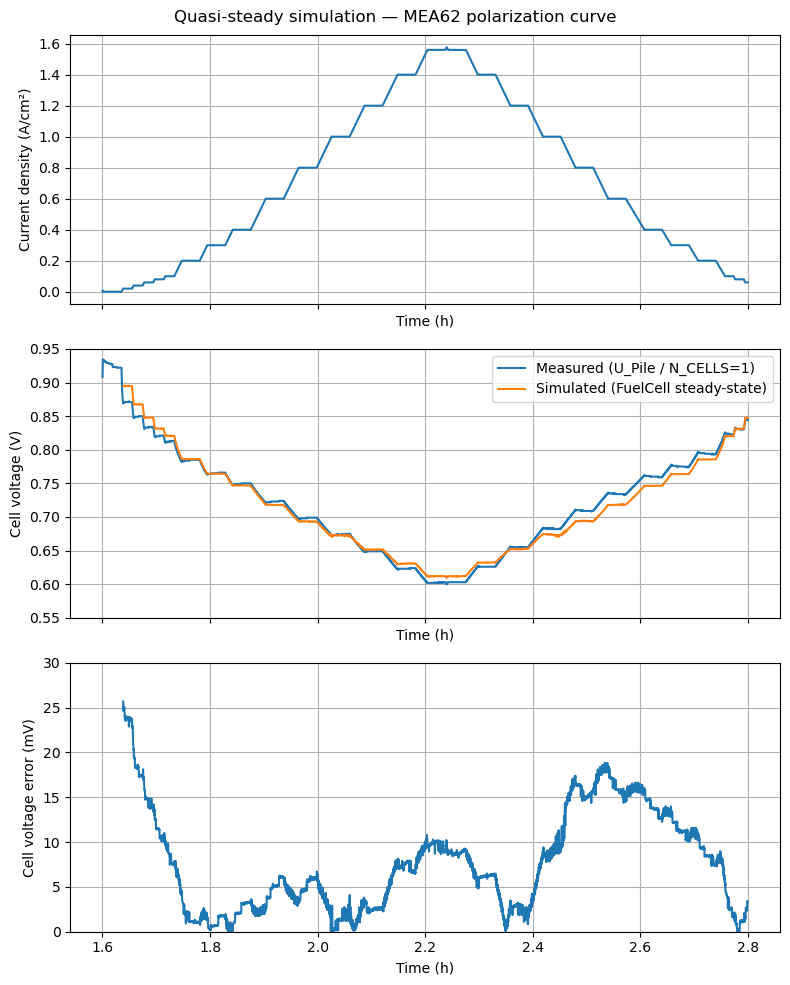

In [6]:
time_h = df['Time(h)'].to_numpy()
current_density = df['I_Pile(A)'].to_numpy() / CELL_AREA * 1e-4   # A/cm²
measured_cell_voltage = df['U_Pile(V)'].to_numpy() / N_CELLS

window = (time_h >= T_START_H) & (time_h <= T_END_H)
t_w   = time_h[window]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(t_w, current_density[window])
axes[0].set_ylabel('Current density (A/cm²)')

axes[1].plot(t_w, measured_cell_voltage[window], label=f'Measured (U_Pile / N_CELLS={N_CELLS})')
axes[1].plot(t_w, cell_voltage[window], label='Simulated (FuelCell steady-state)')
axes[1].set_ylabel('Cell voltage (V)')
axes[1].set_ylim([0.55, 0.95])
axes[1].legend()

axes[2].plot(t_w, np.abs(1e3 * (measured_cell_voltage[window] - cell_voltage[window])))
axes[2].set_ylabel('Cell voltage error (mV)')
axes[2].set_ylim([0, 30])

for ax in axes:
    ax.set_xlabel('Time (h)')
    ax.grid()

fig.suptitle('Quasi-steady simulation — MEA62 polarization curve')
fig.tight_layout()
plt.show()